# Data Loading

This notebook loads the customer churn dataset and prepares data for predictive modeling.

The target variable is:

- churn_next_60d

The objective is to predict whether a customer will churn within the next 60 days.

In [3]:
import pandas as pd

snapshot = pd.read_csv("../data/raw/rfm_modeling_snapshot.csv")
snapshot.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [4]:
snapshot.shape

snapshot.info()
snapshot.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   str    
 1   snapshot_date             2400 non-null   str    
 2   city_tier                 2400 non-null   str    
 3   age_group                 2400 non-null   str    
 4   acquisition_channel       2400 non-null   str    
 5   loyalty_tier              1014 non-null   str    
 6   preferred_category        2400 non-null   str    
 7   marketing_consent         2400 non-null   str    
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category_diversity_

loyalty_tier                1386
snapshot_date                  0
city_tier                      0
age_group                      0
customer_id                    0
acquisition_channel            0
preferred_category             0
marketing_consent              0
recency_days                   0
frequency_180d                 0
monetary_180d                  0
return_rate_180d               0
avg_discount_pct_180d          0
avg_rating_180d                0
category_diversity_180d        0
ticket_count_90d               0
negative_ticket_rate_90d       0
avg_resolution_hours_90d       0
days_since_signup              0
sessions_30d                   0
product_views_30d              0
cart_adds_30d                  0
wishlist_adds_30d              0
abandoned_carts_30d            0
email_opens_30d                0
campaign_clicks_30d            0
last_visit_days_ago            0
churn_next_60d                 0
split                          0
dtype: int64

In [5]:
missing = snapshot.isnull().sum().reset_index()
missing.columns = ["feature","missing"]

missing.to_csv(
    "../outputs/tables/missing_values.csv",
    index=False
)

# Leakage Prevention

Only features available on or before snapshot_date are used.

The following columns are removed:

- customer_id
- snapshot_date
- split

These fields are identifiers or dataset management fields and should not be used as predictors.

In [6]:
snapshot.columns.tolist()

['customer_id',
 'snapshot_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'churn_next_60d',
 'split']

In [7]:
snapshot["split"].value_counts()

split
train         1728
validation     336
test           336
Name: count, dtype: int64

In [8]:
train = snapshot[snapshot["split"]=="train"]
valid = snapshot[snapshot["split"]=="validation"]
test = snapshot[snapshot["split"]=="test"]

In [9]:
TARGET = "churn_next_60d"
X_train = train.drop(columns=[TARGET,"customer_id","snapshot_date","split"])
y_train = train[TARGET]

X_valid = valid.drop(columns=[TARGET,"customer_id","snapshot_date","split"])
y_valid = valid[TARGET]

X_test = test.drop(columns=[TARGET,"customer_id","snapshot_date","split"])
y_test = test[TARGET]

In [10]:
cat_cols = X_train.select_dtypes(include="object").columns
cat_cols

C:\Users\shrit\AppData\Local\Temp\ipykernel_11908\1847301736.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include="object").columns


Index(['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier',
       'preferred_category', 'marketing_consent'],
      dtype='str')

In [11]:
X_train = pd.get_dummies(X_train)
X_valid = pd.get_dummies(X_valid)
X_test = pd.get_dummies(X_test)

X_valid = X_valid.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Baseline Model

Logistic Regression is used as a simple benchmark model.

In [13]:
!pip install scikit-learn
import sklearn
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train,y_train)

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB 5.3 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/8.3 MB 11.0 MB/s eta 0:00:01
   --------- ------------------------------ 1.9/8.3 MB 15.2 MB/s eta 0:00:01
   ------------- -------------------------- 2.9/8.3 MB 15.4 MB/s eta 0:00:01
   ------------------ --------------------- 3.8/8.3 MB 16.2 MB/s eta 0:00:01
   ----------------------- ---------------- 4.8/8.3 MB 17.0 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 18.3 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 18.8 MB/s eta 0:00:01
   ---------------------------------------  8.3/8.3 MB 20.3 MB/s eta 0:00:01
   ---------------------------------------  8.3/8.3 MB 20.3 MB/s eta 0:00:01
   ---------------------------

c:\Users\shrit\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [14]:
lr_probs = lr.predict_proba(X_test)[:,1]

# Stronger Model

Random Forest is trained to capture nonlinear relationships and interactions between features.

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [16]:
rf_probs = rf.predict_proba(X_test)[:,1]

In [17]:
from sklearn.metrics import roc_auc_score

print(
    "LR AUC:",
    roc_auc_score(y_test,lr_probs)
)

print(
    "RF AUC:",
    roc_auc_score(y_test,rf_probs)
)

LR AUC: 0.8855229591836734
RF AUC: 0.8815901360544217


In [18]:
threshold = 0.40
preds = (rf_probs >= threshold).astype(int)

# Threshold Selection

A threshold of 0.40 was selected to increase churn detection recall.

Missing a churner is more expensive than contacting a customer who would have stayed.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [20]:
metrics = {
    "accuracy": accuracy_score(y_test,preds),
    "precision": precision_score(y_test,preds),
    "recall": recall_score(y_test,preds),
    "f1": f1_score(y_test,preds),
    "roc_auc": roc_auc_score(y_test,rf_probs)
}

metrics

{'accuracy': 0.8184523809523809,
 'precision': 0.7923497267759563,
 'recall': 0.8630952380952381,
 'f1': 0.8262108262108262,
 'roc_auc': 0.8815901360544217}

In [21]:
import json

with open(
    "../outputs/metrics.json",
    "w"
) as f:
    json.dump(metrics,f,indent=4)

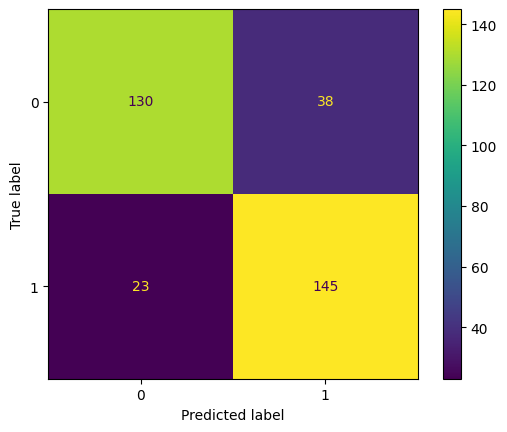

In [24]:
!pip install matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds
)

plt.savefig(
    "../outputs/charts/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [25]:
importance = pd.DataFrame({
    "feature":X_train.columns,
    "importance":rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,feature,importance
0,recency_days,0.265839
18,last_visit_days_ago,0.154491
2,monetary_180d,0.083275
1,frequency_180d,0.054744
4,avg_discount_pct_180d,0.048592
6,category_diversity_180d,0.044297
12,product_views_30d,0.044169
10,days_since_signup,0.043120
11,sessions_30d,0.038051
5,avg_rating_180d,0.020653


In [26]:
importance.to_csv(
    "../outputs/tables/feature_importance.csv",
    index=False
)

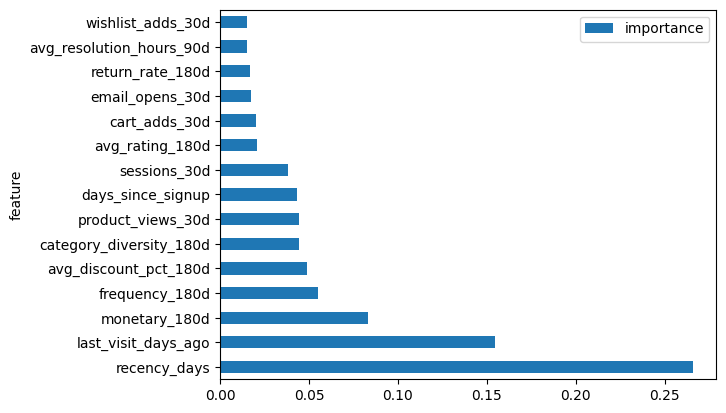

In [27]:
importance.head(15).plot.barh(
    x="feature",
    y="importance"
)

plt.savefig(
    "../outputs/charts/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [28]:
import pickle

with open(
    "../outputs/model.pkl",
    "wb"
) as f:
    pickle.dump(rf,f)

In [29]:
#false positives
fp = test.copy()

fp["prediction"] = preds

false_positives = fp[
    (fp[TARGET]==0) &
    (fp["prediction"]==1)
]

false_positives.head(10)

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,prediction
43,CUST00044,2025-09-30,Tier 2,35-44,Google Search,NaN,Baby Care,Yes,72,1,...,27,2,1,1,4,2,10,0,test,1
108,CUST00109,2025-09-30,Tier 1,25-34,Instagram,Silver,Skin Care,Yes,92,2,...,4,0,0,0,3,1,16,0,test,1
334,CUST00335,2025-09-30,Tier 2,45+,Instagram,NaN,Skin Care,Yes,148,2,...,40,1,1,0,3,1,22,0,test,1
436,CUST00437,2025-09-30,Tier 2,35-44,Marketplace,Silver,Baby Care,Yes,151,1,...,0,0,0,0,0,0,33,0,test,1
490,CUST00491,2025-09-30,Tier 1,25-34,Organic,Silver,Makeup,Yes,97,1,...,40,3,2,1,5,1,20,0,test,1
579,CUST00580,2025-09-30,Tier 2,35-44,Referral,NaN,Fragrance,Yes,74,1,...,23,1,0,0,5,1,17,0,test,1
587,CUST00588,2025-09-30,Tier 1,18-24,Referral,Silver,Skin Care,No,76,1,...,32,1,0,0,0,0,0,0,test,1
733,CUST00734,2025-09-30,Tier 2,25-34,Google Search,NaN,Skin Care,Yes,89,2,...,19,3,0,2,4,0,30,0,test,1
814,CUST00815,2025-09-30,Tier 3,18-24,Referral,Silver,Skin Care,Yes,137,2,...,12,1,0,0,0,0,31,0,test,1
877,CUST00878,2025-09-30,Tier 2,18-24,Marketplace,NaN,Baby Care,Yes,134,2,...,66,3,3,2,6,1,14,0,test,1


In [31]:
importance.to_csv(
    "../outputs/tables/false_positives.csv",
    index=False
)

In [30]:
#false negatives
false_negatives = fp[
    (fp[TARGET]==1) &
    (fp["prediction"]==0)
]

false_negatives.head(10)

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,prediction
183,CUST00184,2025-09-30,Tier 1,18-24,Instagram,Platinum,Wellness,No,14,3,...,18,1,1,0,0,0,6,1,test,0
246,CUST00247,2025-09-30,Tier 2,25-34,Marketplace,NaN,Hair Care,Yes,57,2,...,13,1,0,1,5,2,14,1,test,0
413,CUST00414,2025-09-30,Tier 2,25-34,Marketplace,NaN,Baby Care,Yes,3,1,...,30,3,1,2,6,1,0,1,test,0
437,CUST00438,2025-09-30,Tier 1,25-34,Marketplace,Platinum,Baby Care,Yes,64,3,...,22,1,1,1,7,2,22,1,test,0
530,CUST00531,2025-09-30,Tier 2,25-34,Instagram,NaN,Hair Care,Yes,43,2,...,4,0,0,0,2,0,19,1,test,0
591,CUST00592,2025-09-30,Tier 2,18-24,Referral,NaN,Makeup,Yes,20,1,...,8,2,1,1,0,0,1,1,test,0
595,CUST00596,2025-09-30,Tier 3,25-34,Referral,Gold,Skin Care,Yes,50,1,...,62,2,2,1,7,1,9,1,test,0
837,CUST00838,2025-09-30,Tier 3,18-24,Google Search,NaN,Skin Care,Yes,9,1,...,65,4,1,1,7,1,12,1,test,0
865,CUST00866,2025-09-30,Tier 3,25-34,Referral,NaN,Makeup,No,26,1,...,21,1,1,1,0,0,1,1,test,0
902,CUST00903,2025-09-30,Tier 1,25-34,Marketplace,Silver,Fragrance,No,42,1,...,61,6,3,3,0,0,11,1,test,0


In [32]:
importance.to_csv(
    "../outputs/tables/false_negatives.csv",
    index=False
)